In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Load final processed CSV
# -----------------------------
CSV = Path("../../data/gravity/Onyx_Profile_Harmonica_LiDAR_Corrected.csv")
df = pd.read_csv(CSV)

OUT = Path("../../figures/Final_figures")
OUT.mkdir(exist_ok=True)

x = df["station_m"].astype(float)

def rel(y):
    """Plot values relative to their own mean so processing stages compare clearly."""
    return y - np.nanmean(y)

def detrend(y, x=x):
    """Remove best-fit linear regional trend."""
    p = np.polyfit(x, y, 1)
    return y - np.polyval(p, x)



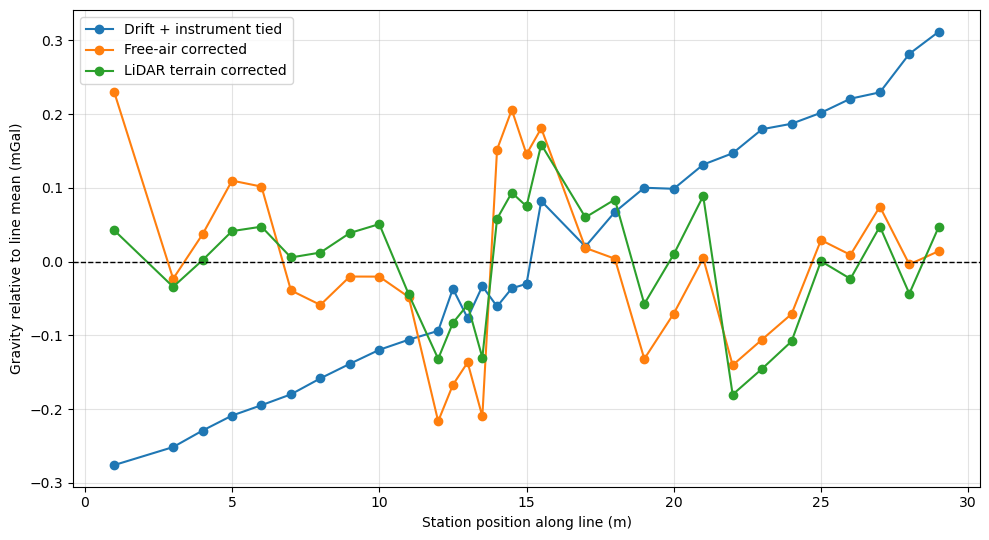

In [5]:
# -----------------------------
# Figure 1: Processing stages, normalized
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["gravity_tied_mgal"]), "o-", label="Drift + instrument tied")
plt.plot(x, rel(df["gravity_free_air_only_mgal"]), "o-", label="Free-air corrected")
plt.plot(x, rel(df["gravity_harmonica_lidar_corrected_mgal"]), "o-", label="LiDAR terrain corrected")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Gravity relative to line mean (mGal)")
#plt.title("Gravity Processing Stages")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUT / "Grav_01_processing_stages_relative.png", dpi=300)
plt.show()



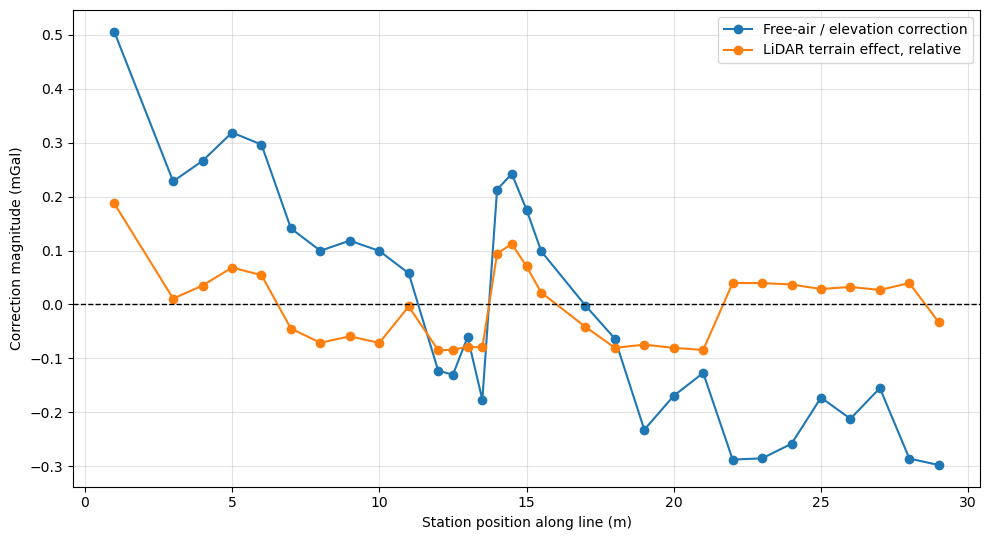

In [6]:
# -----------------------------
# Figure 2: Correction terms only
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["free_air_correction_mgal"]), "o-", label="Free-air / elevation correction")
plt.plot(x, df["harmonica_gz_relative_mgal"], "o-", label="LiDAR terrain effect, relative")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Correction magnitude (mGal)")
#plt.title("Elevation and LiDAR Terrain Correction Terms")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUT / "Grav_02_Elev_LiDAR_Corrections.png", dpi=300)
plt.show()



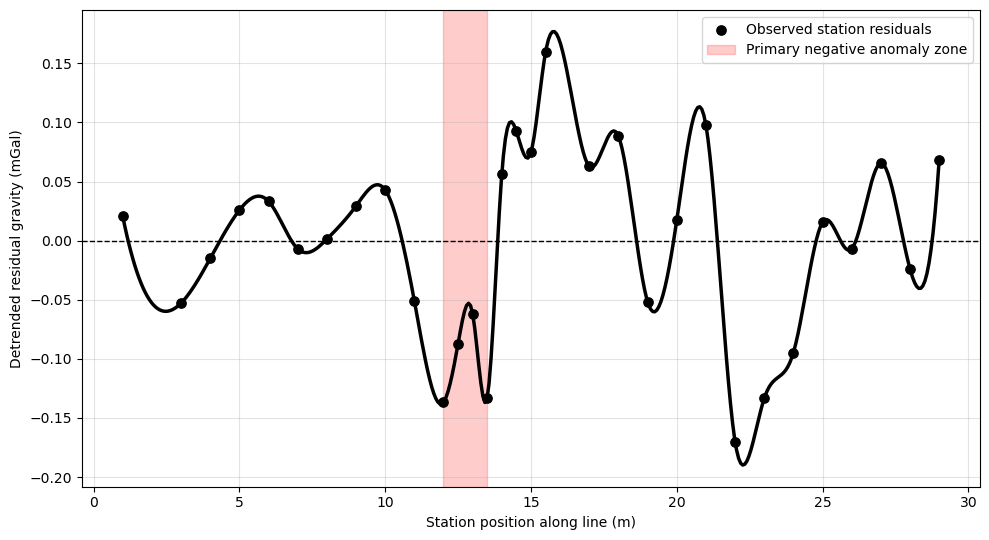

In [11]:
# # -----------------------------
# # Figure 3: Final residual anomaly after removing regional trend
# # -----------------------------
# final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
# resid = detrend(final)

# plt.figure(figsize=(10, 5.5))
# plt.plot(x, resid, "ko-", label="Final LiDAR-corrected residual")

# # highlight likely mine-shaft anomaly zone
# plt.axvspan(12, 13.5, alpha=0.2, label="Primary negative anomaly zone")

# plt.axhline(0, color="k", linestyle="--", linewidth=1)
# plt.xlabel("Station position along line (m)")
# plt.ylabel("Detrended residual gravity (mGal)")
# #plt.title("Final Residual Gravity Anomaly")
# plt.legend()
# plt.grid(True, alpha=0.35)
# plt.tight_layout()
# plt.savefig(OUT / "Grav_03_final_residual_anomaly.png", dpi=300)
# plt.show()

from scipy.interpolate import make_interp_spline

# -----------------------------
# Figure 3: Final residual anomaly after removing regional trend
# -----------------------------
final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
resid = detrend(final)

# Put x and residual into one dataframe
plot_df = pd.DataFrame({
    "x": x,
    "resid": resid
})

# Sort and average duplicate station positions
plot_df = (
    plot_df
    .groupby("x", as_index=False)
    .mean()
    .sort_values("x")
)

x_plot = plot_df["x"].to_numpy()
resid_plot = plot_df["resid"].to_numpy()

# Smooth curve
x_smooth = np.linspace(x_plot.min(), x_plot.max(), 400)
spline = make_interp_spline(x_plot, resid_plot, k=3)
resid_smooth = spline(x_smooth)

plt.figure(figsize=(10, 5.5))

plt.plot(
    x_smooth,
    resid_smooth,
    color="black",
    linewidth=2.5,
    #label="Smoothed LiDAR-corrected residual"
)

plt.scatter(
    x_plot,
    resid_plot,
    color="black",
    s=45,
    zorder=5,
    label="Observed station residuals"
)

plt.axvspan(
    12,
    13.5,
    alpha=0.2,
    color="red",
    label="Primary negative anomaly zone"
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)

plt.xlabel("Station position along line (m)")
plt.ylabel("Detrended residual gravity (mGal)")
plt.legend()
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(
    OUT / "Grav_03_final_residual_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()